In [4]:
import h5py
import numpy as np

PR = 0  # Change as needed
last_n = 78000  # number of last time steps to read

# File paths
u_file = f"/data92/PeterChang/Dycore_data/PR{PR}/u/PR{PR}_500_20000day_u_6hourly.h5"
v_file = f"/data92/PeterChang/Dycore_data/PR{PR}/v/PR{PR}_500_20000day_v_6hourly.h5"
t_file = f"/data92/PeterChang/Dycore_data/PR{PR}/t/PR{PR}_500_20000day_t_6hourly.h5"
w_file = f"/data92/PeterChang/Dycore_data/PR{PR}/w/PR{PR}_500_20000day_w_6hourly.h5"
ps_file = f"/data92/PeterChang/Dycore_data/PR{PR}/ps/PR{PR}_500_20000day_ps_6hourly.h5"

# Read only the last `last_n` time steps of the main dataset in each file
def read_last_timesteps(file_path, last_n):
    with h5py.File(file_path, 'r') as f:
        # Assume there's only one dataset or we know the key
        data_key = list(f.keys())[0]  # e.g., 'u'
        dset = f[data_key]
        total_time = dset.shape[0]
        return dset[-last_n:, ...]  # last 5000 time steps

# Load data slices
u_last = read_last_timesteps(u_file, last_n)
v_last = read_last_timesteps(v_file, last_n)
t_last = read_last_timesteps(t_file, last_n)
w_last = read_last_timesteps(w_file, last_n)
ps_last = read_last_timesteps(ps_file, last_n)  # shape likely (time, y, x)

# Confirm shapes (optional)
print("u:", u_last.shape)
print("v:", v_last.shape)
print("t:", t_last.shape)
print("w:", w_last.shape)
print("ps:", ps_last.shape)


u: (78000, 20, 64, 128)
v: (78000, 20, 64, 128)
t: (78000, 20, 64, 128)
w: (78000, 20, 64, 128)
ps: (78000, 1, 64, 128)


In [5]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

# Constants
a = 6.371e6       # Earth radius (m)
p0 = 100000       # Reference pressure (Pa)
R = 287.0         # Gas constant for dry air (J/kg/K)
cp = 1004.0       # Specific heat at constant pressure (J/kg/K)

# Configuration
# PR = 0
# last_n = 78000
lev = np.linspace(1, 0.1, 20)  # sigma levels

# File paths
base_path = f"/data92/PeterChang/Dycore_data/PR{PR}/"
u_file = base_path + f"u/PR{PR}_500_20000day_u_6hourly.h5"
v_file = base_path + f"v/PR{PR}_500_20000day_v_6hourly.h5"
t_file = base_path + f"t/PR{PR}_500_20000day_t_6hourly.h5"
ps_file = base_path + f"ps/PR{PR}_500_20000day_ps_6hourly.h5"

# def read_last_timesteps(file_path, last_n):
#     with h5py.File(file_path, 'r') as f:
#         key = list(f.keys())[0]
#         return f[key][-last_n:]


# # Load data
# u_last = read_last_timesteps(u_file, last_n)
# v_last = read_last_timesteps(v_file, last_n)
# t_last = read_last_timesteps(t_file, last_n)
# ps_last = read_last_timesteps(ps_file, last_n)[:, 0, :, :]  # (time, lat, lon)

# ============================
# 讀取「指定 time index」的 function
# ============================

def read_timesteps_by_index(file_path, time_indices, ps_surface=False):
    """
    從 h5 檔讀出指定 time index 的資料。
    
    Parameters
    ----------
    file_path : str
        h5 檔路徑
    time_indices : array-like of int
        要讀的時間 index (0-based)
    ps_surface : bool
        如果是 ps 檔、而且資料 shape 是 (time, lev, lat, lon)，就會回傳第 0 層：[:, 0, :, :]

    Returns
    -------
    data : np.ndarray
        按照 time_indices 抽出來的資料
    """
    time_indices = np.asarray(time_indices, dtype=int)

    with h5py.File(file_path, 'r') as f:
        key = list(f.keys())[0]          # 假設每個檔案只有一個主 dataset
        data = f[key][time_indices]      # 用 fancy indexing 直接抽指定時間

        if ps_surface:
            # 例如原始 shape: (time, lev, lat, lon) -> 只取第 0 層
            data = data[:, 0, :, :]

    return data

# ============================
# 使用範例：讀 PC1 正/負 phase 的 u, v, t, ps
# ============================
# read PC1 positive and negative time index
with h5py.File("/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux/New_PC1_time_idx/PC1_positive_1std_PR0.h5", 'r') as F:
    pc1_pos_idx = F['time_idx_pos'][0]  # (N,) array of integers

with h5py.File("/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux/New_PC1_time_idx/PC1_negative_1std_PR0.h5", 'r') as F:
    pc1_neg_idx = F['time_idx_neg'][0]  # (N,) array of integers

# PC1 positive composites
u_pos  = read_timesteps_by_index(u_file,  pc1_pos_idx)
v_pos  = read_timesteps_by_index(v_file,  pc1_pos_idx)
t_pos  = read_timesteps_by_index(t_file,  pc1_pos_idx)
ps_pos = read_timesteps_by_index(ps_file, pc1_pos_idx, ps_surface=True)

# PC1 negative composites
u_neg  = read_timesteps_by_index(u_file,  pc1_neg_idx)
v_neg  = read_timesteps_by_index(v_file,  pc1_neg_idx)
t_neg  = read_timesteps_by_index(t_file,  pc1_neg_idx)
ps_neg = read_timesteps_by_index(ps_file, pc1_neg_idx, ps_surface=True)


# # Compute potential temperature
# def compute_theta(T, ps, sigma):
#     ps_expanded = np.repeat(ps[:, None, :, :], T.shape[1], axis=1)
#     p = sigma[None, :, None, None] * ps_expanded
#     theta = T * (p0 / p) ** (R / cp)
#     return theta

# # Zonal and time mean & anomalies
# def mean_and_perturb(field):
#     zonal_mean = np.mean(field, axis=-1)
#     time_mean = np.mean(zonal_mean, axis=0)
#     anomaly = field - zonal_mean[..., None]
#     return time_mean, anomaly

# # Compute means and perturbations
# u_bar, u_prime = mean_and_perturb(u_last)
# v_bar, v_prime = mean_and_perturb(v_last)
# t_bar, t_prime = mean_and_perturb(t_last)

# theta = compute_theta(t_last, ps_last, lev)
# theta_bar, theta_prime = mean_and_perturb(theta)

# # Compute flux terms
# uv_prime = np.mean(u_prime * v_prime, axis=(0, 3))         # (lev, lat)
# vtheta_prime = np.mean(v_prime * theta_prime, axis=(0, 3)) # (lev, lat)
# dtheta_dsigma = np.gradient(theta_bar, lev, axis=0)
# dtheta_dsigma[np.abs(dtheta_dsigma)<50] = np.nan

# # Latitude and geometry
# lat_deg = np.linspace(-90, 90, 64)
# lat_rad = np.radians(lat_deg)
# cos_phi = np.cos(lat_rad)

# # EP Flux
# F_phi = -a * cos_phi[None, :] * uv_prime
# F_sigma = a * cos_phi[None, :] * np.sin(lat_rad)[None, :]* vtheta_prime / dtheta_dsigma


In [46]:
# ============================
# 已有的 function（照舊）
# ============================

def compute_theta(T, ps, sigma):
    """
    T:   (time, lev, lat, lon)
    ps:  (time, lat, lon)
    sigma: (lev,)
    """
    ps_expanded = np.repeat(ps[:, None, :, :], T.shape[1], axis=1)  # (time, lev, lat, lon)
    p = sigma[None, :, None, None] * ps_expanded
    theta = T * (p0 / p) ** (R / cp)
    return theta

def mean_and_perturb(field):
    """
    field: (time, lev, lat, lon)

    回傳：
      time_mean : (lev, lat)
      anomaly   : (time, lev, lat, lon)  （去 zonal mean 之後的擾動）
    """
    zonal_mean = np.mean(field, axis=-1)    # (time, lev, lat)
    time_mean  = np.mean(zonal_mean, axis=0) # (lev, lat)
    anomaly    = field - zonal_mean[..., None]
    return time_mean, anomaly


# ============================
# EP flux 計算 function
# ============================

def compute_EP_flux(u, v, T, ps, sigma, lat_deg, a, nan_threshold=50.0):
    """
    u, v, T: (time, lev, lat, lon)
    ps:      (time, lat, lon)
    sigma:   (lev,)
    lat_deg: (nlat,) 緯度（度）
    a:       行星半徑（例如地球半徑）

    回傳：字典，包含 EP flux 以及一些中間量
    """
    # 緯度、幾何因子
    lat_rad = np.radians(lat_deg)
    cos_phi = np.cos(lat_rad)
    sin_phi = np.sin(lat_rad)

    # mean / perturbations
    u_bar, u_prime = mean_and_perturb(u)        # u_bar: (lev, lat)
    v_bar, v_prime = mean_and_perturb(v)
    theta = compute_theta(T, ps, sigma)         # (time, lev, lat, lon)
    theta_bar, theta_prime = mean_and_perturb(theta)

    # 擾動通量
    uv_prime      = np.mean(u_prime * v_prime, axis=(0, 3))         # (lev, lat)
    vtheta_prime  = np.mean(v_prime * theta_prime, axis=(0, 3))     # (lev, lat)

    # 垂直梯度 dθ/dσ
    dtheta_dsigma = np.gradient(theta_bar, sigma, axis=0)           # (lev, lat)
    dtheta_dsigma[np.abs(dtheta_dsigma) < nan_threshold] = np.nan   # 避免除以太小的數

    # EP Flux components
    F_phi   = -a * cos_phi[None, :] * uv_prime 
    F_sigma =  a * cos_phi[None, :] * sin_phi[None, :] * vtheta_prime / dtheta_dsigma

    return {
        "u_bar": u_bar,
        "v_bar": v_bar,
        "theta_bar": theta_bar,
        "uv_prime": uv_prime,
        "vtheta_prime": vtheta_prime,
        "dtheta_dsigma": dtheta_dsigma,
        "F_phi": F_phi,
        "F_sigma": F_sigma,
    }


# ============================
# 緯度與幾何（照你原本的）
# ============================

lat_deg = np.linspace(-90, 90, 64)   # 確認這裡的 64 要跟資料的 lat 維度一致
a = 6.371e6                          # 例如地球半徑，可換成你原本用的 a


# ============================
# 對 PC1 positive / negative 各算 EP flux
# ============================

# PC1 positive
EP_pos = compute_EP_flux(
    u_pos, v_pos, t_pos, ps_pos,
    sigma=lev,        # 你原本 vertical coordinate 變數
    lat_deg=lat_deg,
    a=a
)
F_phi_pos   = EP_pos["F_phi"]        # (lev, lat)
F_sigma_pos = EP_pos["F_sigma"]      # (lev, lat)

# PC1 negative
EP_neg = compute_EP_flux(
    u_neg, v_neg, t_neg, ps_neg,
    sigma=lev,
    lat_deg=lat_deg,
    a=a
)
F_phi_neg   = EP_neg["F_phi"]
F_sigma_neg = EP_neg["F_sigma"]


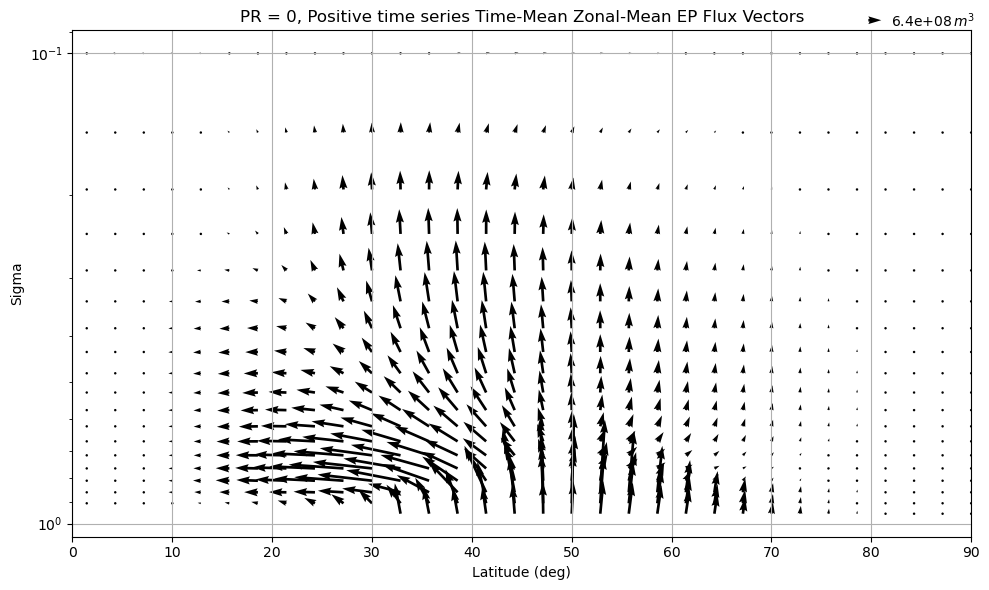

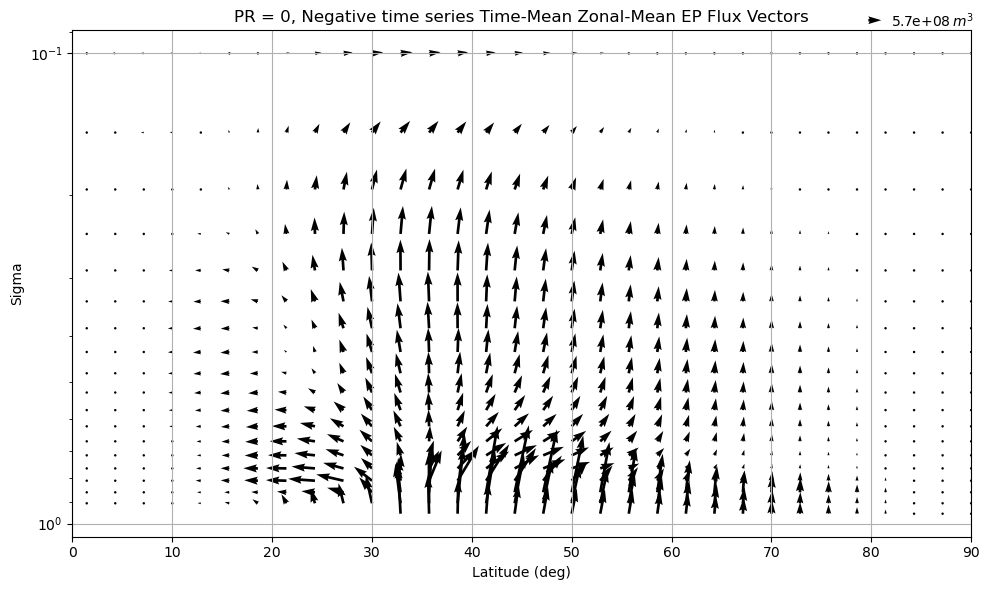

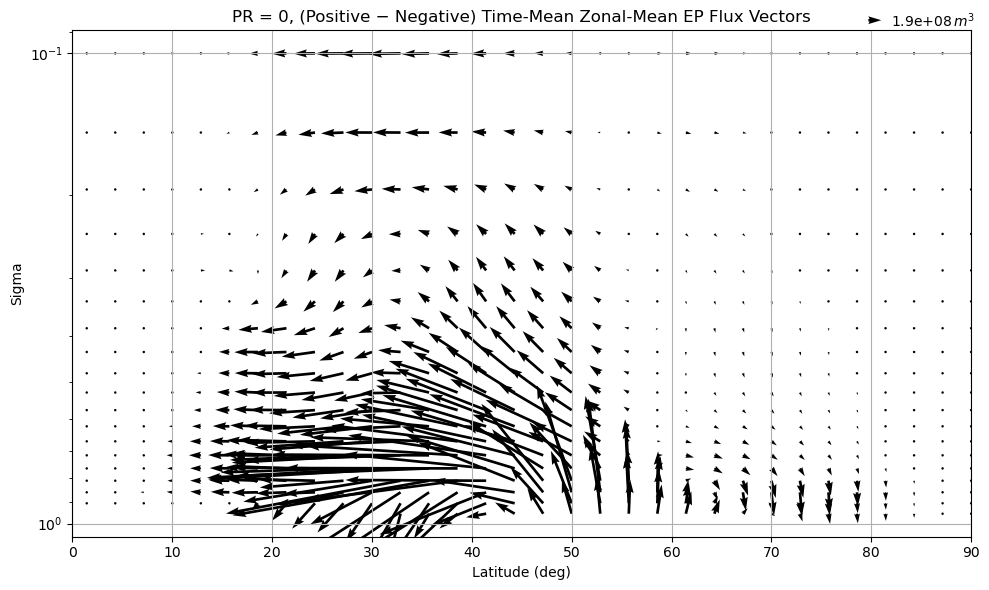

In [50]:
# ============================================
# Meshgrid for plotting
# ============================================
Lat, Sigma = np.meshgrid(lat_deg, lev)  # Lat: (lev, lat), Sigma: (lev, lat)

# ============================================
# Helper function to plot one EP flux panel
# ============================================
def plot_EP_flux_panel(Lat, Sigma, F_phi, F_sigma, PR, title_suffix,
                       quivArgs, GetAxSize, scale_factor=1000.0,
                       xlim=(0, 90)):

    fig, ax = plt.subplots(figsize=(10, 6))

    # NOTE: Sigma[1:,:] & F_[1:,:] 跟你原本一樣，略過最頂層
    Q = ax.quiver(
        Lat[1:, :],                      # x
        Sigma[1:, :],                    # y
        F_phi[1:, :],                    # U
        -F_sigma[1:, :] * scale_factor,  # V 乘 1000 並加負號
        **quivArgs
    )

    # 更新 figure 才抓得到 quiver 的 scale
    fig.canvas.draw()
    U = Q.scale

    # 用你的 GetAxSize 計算 quiver key
    width, height = GetAxSize(fig, ax)
    ax.quiverkey(
        Q, 0.9, 1.02, U / width,
        label=r'{0:.1e}$\,m^3$'.format(U),
        labelpos='E',
        coordinates='axes'
    )

    ax.set_xlim(xlim)
    ax.invert_yaxis()
    ax.set_xlabel('Latitude (deg)')
    ax.set_ylabel('Sigma')
    ax.set_yscale("log")
    ax.set_title(f'PR = {PR}, {title_suffix}')
    ax.grid()
    plt.tight_layout()
    plt.show()

    return fig, ax


# ============================================
# 圖 1：Positive time series EP Flux
# ============================================
fig1, ax1 = plot_EP_flux_panel(
    Lat=Lat,
    Sigma=Sigma,
    F_phi=F_phi_pos,
    F_sigma=F_sigma_pos,
    PR=PR,
    title_suffix='Positive time series Time-Mean Zonal-Mean EP Flux Vectors',
    quivArgs=quivArgs,
    GetAxSize=GetAxSize
)

# ============================================
# 圖 2：Negative time series EP Flux
# ============================================
fig2, ax2 = plot_EP_flux_panel(
    Lat=Lat,
    Sigma=Sigma,
    F_phi=F_phi_neg,
    F_sigma=F_sigma_neg,
    PR=PR,
    title_suffix='Negative time series Time-Mean Zonal-Mean EP Flux Vectors',
    quivArgs=quivArgs,
    GetAxSize=GetAxSize
)

# ============================================
# 圖 3：Positive − Negative 差值 EP Flux
# ============================================
F_phi_diff   = F_phi_pos   - F_phi_neg
F_sigma_diff = F_sigma_pos - F_sigma_neg

fig3, ax3 = plot_EP_flux_panel(
    Lat=Lat,
    Sigma=Sigma,
    F_phi=F_phi_diff,
    F_sigma=F_sigma_diff,
    PR=PR,
    title_suffix='(Positive − Negative) Time-Mean Zonal-Mean EP Flux Vectors',
    quivArgs=quivArgs,
    GetAxSize=GetAxSize
)
